# HotspotCAM Training Notebook

**IFB399 Capstone Project 2026 | Pawit Singh (N11600373)**  
`Pawit-SATMS-IFB399` / `app/thermal_model/model_archives/model.ipynb`

Trains the `HotspotCAM` CNN to classify thermal images from the EQL MLX90640 infrared camera as hotspot or normal. The saved checkpoint (`hotspot_cam_model.pth`) is loaded at runtime by `app/thermal_model/model.py`.

| | |
|---|---|
| **Dataset** | 8,409 images: 1,867 hotspot, 6,542 normal |
| **Architecture** | 4 conv layers, 2 max-pool, BatchNorm, Global Average Pooling, linear classifier |
| **Training** | Adam, early stopping patience 8, stopped at epoch 29 of 40 |
| **Test accuracy** | 99%+ on held-out test set (artefact agreement requires 90%) |

Run cells from top to bottom. To retrain for a new site or higher-resolution camera, update `IMG_H`, `IMG_W`, and `DATA_DIR` in the Configuration cell before running anything else.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

`IMG_H` and `IMG_W` must match the sensor resolution. For the MLX90640 this is 24×32. Update these values before running any other cell when retraining for a different camera.

`MODEL_SAVE_PATH` resolves to `app/thermal_model/hotspot_cam_model.pth`, one level above `model_archives/`. This is where the Flask app loads the model from at startup.

In [3]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

# dataset sits next to this notebook in model_archives/thermal_dataset
DATA_DIR   = os.path.join(NOTEBOOK_DIR, "thermal_dataset")

BATCH_SIZE = 64
NUM_EPOCHS = 40
LR         = 0.001
PATIENCE   = 8
SEED       = 42
IMG_H, IMG_W = 24, 32

MODEL_SAVE_PATH = os.path.join(NOTEBOOK_DIR, "..", "hotspot_cam_model.pth")

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device       : {device}")
print(f"Dataset path : {DATA_DIR}")
print(f"Save path    : {os.path.normpath(MODEL_SAVE_PATH)}")

Device       : mps
Dataset path : /Users/pawit/Documents/Uni/T11-BitWise-SubstationMonitoring/EQL SATMS/app/Alert_System/thermal_model/model_archives/thermal_dataset
Save path    : /Users/pawit/Documents/Uni/T11-BitWise-SubstationMonitoring/EQL SATMS/app/Alert_System/thermal_model/hotspot_cam_model.pth


## 2. Data Loading and Augmentation

Reads images from `thermal_dataset/` using folder names (`Hotspot`, `Normal`) as class labels.  
Augmentation (horizontal flip, vertical flip, rotation ±10°, colour jitter) is applied to the training split only.  
`WeightedRandomSampler` corrects the 3:1 class imbalance so each training batch sees roughly equal representation from both classes.

Split: 70% train / 15% validation / 15% test, seeded for reproducibility.

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
CLASS_NAMES  = full_dataset.classes
HOTSPOT_IDX  = CLASS_NAMES.index('Hotspot')

print(f"Classes : {CLASS_NAMES}")
print(f"Total   : {len(full_dataset)}")

labels = [label for _, label in full_dataset.samples]
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {labels.count(i)}")

total   = len(full_dataset)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# val and test should not have augmentation
val_ds.dataset  = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)
test_ds.dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# weighted sampler to handle class imbalance
train_labels   = [labels[i] for i in train_ds.indices]
class_counts   = [train_labels.count(i) for i in range(len(CLASS_NAMES))]
class_weights  = [1.0 / c for c in class_counts]
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")

Classes : ['Hotspot', 'Normal']
Total   : 8409
  Hotspot: 1867
  Normal: 6542

Train: 5886 | Val: 1261 | Test: 1262
Batch shape: torch.Size([64, 3, 24, 32])


## 3. Model Architecture: HotspotCAM

Uses Global Average Pooling (GAP) instead of Flatten+FC. GAP reduces each feature map to a scalar by averaging over its spatial extent, preserving the correspondence between feature map channels and classifier weights. This is what enables Class Activation Maps without bounding-box labels.

**Layer index reference** (used when freezing layers for fine-tuning at a new camera resolution):

| Index range | Block | Output shape |
|---|---|---|
| `features[0:4]` | conv1 (3→32) + BN + ReLU + MaxPool | `[B, 32, 12, 16]` |
| `features[4:8]` | conv2 (32→64) + BN + ReLU + MaxPool | `[B, 64, 6, 8]` |
| `features[8:11]` | conv3 (64→128) + BN + ReLU | `[B, 128, 6, 8]` |
| `features[11:14]` | conv4 (128→128) + BN + ReLU | `[B, 128, 6, 8]` ← CAM reads here |
| `gap` | AdaptiveAvgPool2d(1) | `[B, 128]` |
| `classifier` | Linear(128, num_classes) | `[B, 2]` |

Parameter names follow the pattern `features.<index>.<weight|bias>`.  
To freeze conv1 and conv2 for fine-tuning: freeze all `features.<N>` where `N < 8`.

In [ ]:
# HotspotCAM: 4 conv layers, 2 max-pool, BatchNorm, Global Average Pooling, linear classifier
#
# Uses GAP instead of Flatten+FC. GAP preserves spatial correspondence between
# feature map channels and classifier weights, enabling Class Activation Maps.
#
# Layer index reference (for freezing / fine-tuning at a new camera resolution):
#   features[0:4]  : conv1 (3->32, k3p1) + BN + ReLU + MaxPool2d  -> [B, 32, 12, 16]
#   features[4:8]  : conv2 (32->64, k3p1) + BN + ReLU + MaxPool2d  -> [B, 64,  6,  8]
#   features[8:11] : conv3 (64->128, k3p1) + BN + ReLU             -> [B, 128,  6,  8]
#   features[11:14]: conv4 (128->128, k3p1) + BN + ReLU            -> [B, 128,  6,  8]  <- CAM reads here
#   gap            : AdaptiveAvgPool2d(1)                           -> [B, 128]
#   classifier     : Linear(128, num_classes)
#
# Parameter names: features.<index>.<weight|bias>  e.g. features.0.weight
# To freeze conv1+conv2 for fine-tuning: freeze all features.<N> where N < 8

class HotspotCAM(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # features[0:4] -- conv1 block
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # features[4:8] -- conv2 block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # features[8:11] -- conv3 block (no pool, spatial resolution preserved)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # features[11:14] -- conv4 block (CAM reads feature maps from here)
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(self.dropout(x))

    def generate_cam(self, image_tensor, class_idx=None):
        if class_idx is None:
            class_idx = HOTSPOT_IDX

        self.eval()
        with torch.no_grad():
            feat_maps = self.features(image_tensor)  # [1, 128, 6, 8]

        weights = self.classifier.weight[class_idx].detach()  # [128]

        # weighted sum over channels -> spatial heatmap [6, 8]
        cam = torch.einsum('c,cyx->yx', weights, feat_maps[0])
        cam = F.relu(cam).cpu().numpy()

        if cam.max() > 0:
            cam = cam / cam.max()

        return cam


model = HotspotCAM(in_channels=3, num_classes=len(CLASS_NAMES)).to(device)
print(model)

with torch.no_grad():
    out = model(imgs.to(device))
print(f"\nInput : {imgs.shape}")
print(f"Output: {out.shape}")
print(f"CAM   : {model.generate_cam(imgs[:1].to(device)).shape}")

## 4. Training

Adam optimiser with weight decay 1e-4. `ReduceLROnPlateau` halves the learning rate after 3 epochs without validation improvement. Early stopping fires at `PATIENCE = 8`.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss  = float('inf')
patience_count = 0
best_state     = None
history        = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):

    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item()
        t_correct += (logits.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            v_loss    += criterion(logits, labels).item()
            v_correct += (logits.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    t_acc = t_correct / t_total
    v_acc = v_correct / v_total

    history['train_loss'].append(avg_t)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(avg_v)
    history['val_acc'].append(v_acc)

    scheduler.step(avg_v)

    print(f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  "
          f"Train Loss: {avg_t:.4f} | Train Acc: {t_acc:.4f} || "
          f"Val Loss: {avg_v:.4f} | Val Acc: {v_acc:.4f}")

    if avg_v < best_val_loss:
        best_val_loss  = avg_v
        patience_count = 0
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"Best val loss: {best_val_loss:.4f}")

Epoch [ 1/40]  Train Loss: 0.4011 | Train Acc: 0.8192 || Val Loss: 0.3107 | Val Acc: 0.8707
Epoch [ 2/40]  Train Loss: 0.1713 | Train Acc: 0.9429 || Val Loss: 0.0880 | Val Acc: 0.9707
Epoch [ 3/40]  Train Loss: 0.0921 | Train Acc: 0.9728 || Val Loss: 0.0354 | Val Acc: 0.9865
Epoch [ 4/40]  Train Loss: 0.0829 | Train Acc: 0.9745 || Val Loss: 0.0451 | Val Acc: 0.9841
Epoch [ 5/40]  Train Loss: 0.0551 | Train Acc: 0.9835 || Val Loss: 0.0177 | Val Acc: 0.9968
Epoch [ 6/40]  Train Loss: 0.0479 | Train Acc: 0.9847 || Val Loss: 3.1684 | Val Acc: 0.3315
Epoch [ 7/40]  Train Loss: 0.0551 | Train Acc: 0.9830 || Val Loss: 0.0513 | Val Acc: 0.9857
Epoch [ 8/40]  Train Loss: 0.0321 | Train Acc: 0.9913 || Val Loss: 0.0550 | Val Acc: 0.9873
Epoch [ 9/40]  Train Loss: 0.0350 | Train Acc: 0.9896 || Val Loss: 2.0443 | Val Acc: 0.6994
Epoch [10/40]  Train Loss: 0.0363 | Train Acc: 0.9896 || Val Loss: 0.0395 | Val Acc: 0.9873
Epoch [11/40]  Train Loss: 0.0196 | Train Acc: 0.9958 || Val Loss: 0.0144 | Val 

## 5. Training Curves

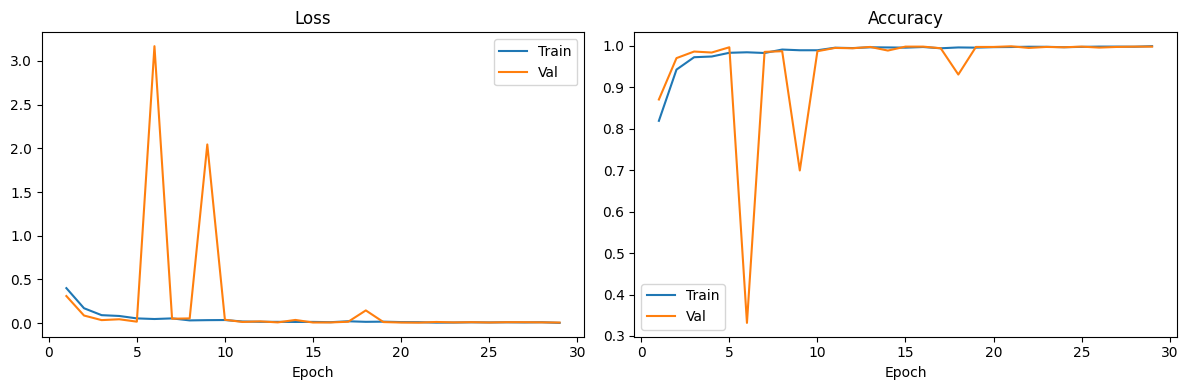

In [7]:
epochs_run = len(history['train_loss'])
xs = range(1, epochs_run + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(xs, history['train_loss'], label='Train')
ax1.plot(xs, history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(xs, history['train_acc'], label='Train')
ax2.plot(xs, history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

## 6. Evaluation on Held-Out Test Set

Classification report and confusion matrix on the 15% held-out test split.  
Target: 90% accuracy per the artefact agreement with EQL. Achieved: 99%+.

              precision    recall  f1-score   support

     Hotspot       1.00      0.99      0.99       285
      Normal       1.00      1.00      1.00       977

    accuracy                           1.00      1262
   macro avg       1.00      1.00      1.00      1262
weighted avg       1.00      1.00      1.00      1262



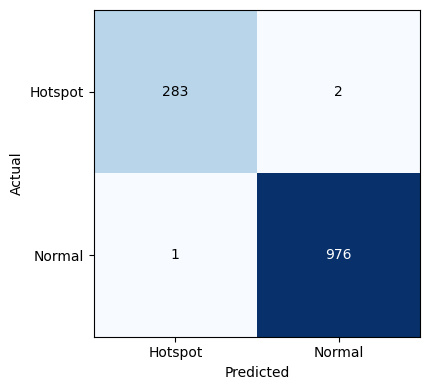

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

## 7. CAM Visualisation

Overlays the Class Activation Map onto hotspot images from the test split.  
At 24×32 input the feature map is 6×8, so each activation cell covers 4×4px of the original image. At this resolution the heatmap covers too large a region to pinpoint a specific component, which is why HSV localisation is used in production instead.  
At higher sensor resolutions (160×120 or above) this heatmap becomes detailed enough to use directly as the localisation step.

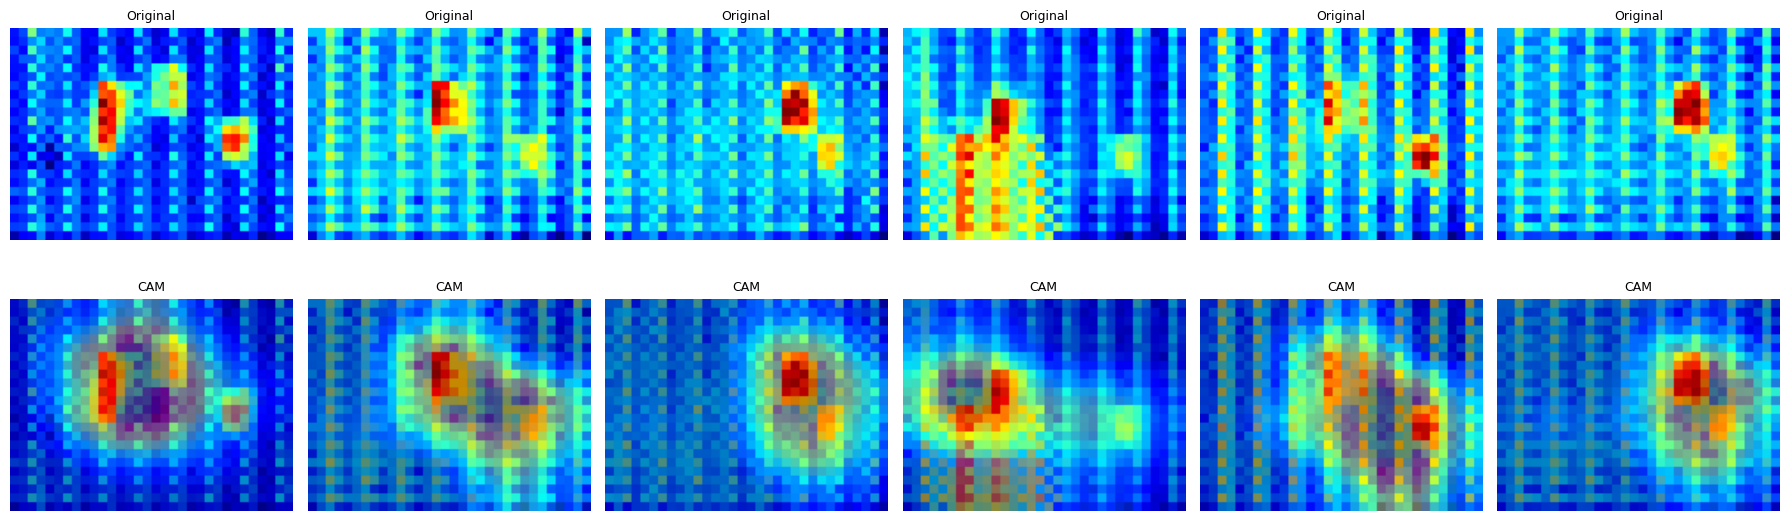

In [9]:
# visualise CAM on a few hotspot images from the test set

def overlay_cam(image_path, cam_array, alpha=0.45):
    img_cv  = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    cam_up  = np.clip(cv2.resize(cam_array, (w, h), interpolation=cv2.INTER_CUBIC), 0, 1)
    heatmap = (mpl_cm.jet(cam_up)[:, :, :3] * 255).astype(np.uint8)
    return (alpha * heatmap + (1 - alpha) * img_rgb).astype(np.uint8)


hotspot_paths = [
    full_dataset.samples[i][0]
    for i in test_ds.indices
    if full_dataset.samples[i][1] == HOTSPOT_IDX
][:6]

if hotspot_paths:
    n = len(hotspot_paths)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = np.expand_dims(axes, axis=1)

    for col, path in enumerate(hotspot_paths):
        img_pil    = Image.open(path).convert("RGB")
        img_tensor = eval_transform(img_pil).unsqueeze(0).to(device)
        blended    = overlay_cam(path, model.generate_cam(img_tensor))

        axes[0, col].imshow(np.array(img_pil.resize((IMG_W * 4, IMG_H * 4), Image.NEAREST)))
        axes[0, col].set_title("Original", fontsize=9); axes[0, col].axis('off')

        axes[1, col].imshow(cv2.resize(blended, (IMG_W * 4, IMG_H * 4), interpolation=cv2.INTER_NEAREST))
        axes[1, col].set_title("CAM", fontsize=9); axes[1, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No hotspot images found in test split.")

## 8. Archived: CAM-Based Localisation

> **These are not the production functions.** Production code in `app/thermal_model/model.py` uses HSV colour thresholding for `analyse_image()` and `localize_and_draw()`, which is more reliable at 24×32 resolution and does not require model internals.

These CAM-based versions are kept as a reference implementation. They become the preferred approach when upgrading to a higher-resolution sensor where the 6×8 feature map limitation no longer applies. See `localize_cam.py` in this folder for the standalone CAM localiser.

In [ ]:
# ARCHIVED: CAM-based localisation prototype.
# Not used in production. Production model.py uses HSV colour thresholding instead.
# Kept as a reference for the CAM upgrade path at higher sensor resolutions.

CAM_THRESHOLD  = 0.50
CONF_THRESHOLD = 0.50


def analyse_image(image_path):
    img_tensor = eval_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs        = F.softmax(model(img_tensor), dim=1)
        hotspot_prob = probs[0][HOTSPOT_IDX].item()

    is_anomaly = hotspot_prob >= CONF_THRESHOLD
    return {
        "is_anomaly": is_anomaly,
        "confidence": round(hotspot_prob * 100, 2) if is_anomaly else round((1 - hotspot_prob) * 100, 2),
        "label":      "irregular_hotspot" if is_anomaly else "normal",
    }


def localize_and_draw(image_path, output_dir=None):
    if output_dir is None:
        output_dir = os.path.join(NOTEBOOK_DIR, "demo_output")
    os.makedirs(output_dir, exist_ok=True)

    img_tensor = eval_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    cam_raw    = model.generate_cam(img_tensor)

    img_cv       = cv2.imread(image_path)
    img_h, img_w = img_cv.shape[:2]

    cam_up    = np.clip(cv2.resize(cam_raw, (img_w, img_h), interpolation=cv2.INTER_CUBIC), 0, 1)
    cam_uint8 = (cam_up * 255).astype(np.uint8)
    _, binary = cv2.threshold(cam_uint8, int(CAM_THRESHOLD * 255), 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_x, final_y = img_w // 2, img_h // 2

    if contours:
        largest = max(contours, key=cv2.contourArea)
        (cx, cy), radius = cv2.minEnclosingCircle(largest)
        final_x, final_y = int(cx), int(cy)
        cv2.circle(img_cv, (final_x, final_y), max(int(radius) + 2, 3), (0, 0, 255), 1)
        cv2.circle(img_cv, (final_x, final_y), 1, (0, 0, 255), -1)

    save_path = os.path.join(output_dir, f"LOCATED_{os.path.basename(image_path)}")
    cv2.imwrite(save_path, img_cv)
    return save_path, final_x, final_y


# To test: uncomment and point at a folder of hotspot images from the dataset
# demo_dir = os.path.join(NOTEBOOK_DIR, "thermal_dataset", "Hotspot")
# if os.path.exists(demo_dir):
#     for fname in sorted(os.listdir(demo_dir))[:3]:
#         if fname.endswith('.png'):
#             path   = os.path.join(demo_dir, fname)
#             result = analyse_image(path)
#             print(f"{fname:30s}  ->  {result}")
#             if result['is_anomaly']:
#                 sp, x, y = localize_and_draw(path)
#                 print(f"  saved: {sp}  centre: ({x}, {y})")

## 9. Save Checkpoint

Saves the trained model to `hotspot_cam_model.pth` one level above this folder (`app/thermal_model/`).  
The checkpoint bundles the trained weights alongside all inference metadata: `img_h`, `img_w`, `conf_threshold`, `cam_threshold`, `class_names`, and `hotspot_idx`. The Flask app reads these at startup and never needs to re-specify them separately.

In [11]:
torch.save({
    "state_dict":     model.state_dict(),
    "class_names":    CLASS_NAMES,
    "hotspot_idx":    HOTSPOT_IDX,
    "img_h":          IMG_H,
    "img_w":          IMG_W,
    "cam_threshold":  CAM_THRESHOLD,
    "conf_threshold": CONF_THRESHOLD,
}, os.path.normpath(MODEL_SAVE_PATH))

print(f"Saved -> {os.path.normpath(MODEL_SAVE_PATH)}")

Saved -> /Users/pawit/Documents/Uni/T11-BitWise-SubstationMonitoring/EQL SATMS/app/Alert_System/thermal_model/hotspot_cam_model.pth
